In [25]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
from torchdiffeq import odeint


In [26]:
#settings
start = np.array((0., 1., 1.05))
dt = 0.01
subset_size = 100#50 #cell number
slope = 2#2 #parameter in weight computation
traj_length = int(1e7)#length of trajectory
noise_level = 0#0.3#.9#0.8
sample_size = int(10000)#int(subset_size*50)
epsilon = 1e-4

# Define the Lorenz-63 System
def Lorenz(x):
    x = x.T
    dx = 10 * (x[1] - x[0])
    dy = x[0] * (28 - x[2]) - x[1]
    dz = x[0] * x[1] - (8/3) * x[2]
    f = np.array((dx, dy, dz)).T
    return f

 #trajectory simulation (Euler's method)
def traj(length, starts = start, model = Lorenz):
    x = starts
    traj = np.zeros((length,len(starts)))
    traj[0] = np.array(x)
    for timestep in range(length-1):

        x = x + dt * model(x)

        traj[timestep+1] = np.array(x)

    return traj

def invariant_measure(matrix):
    N = len(matrix)
    rhs = (-1) * (epsilon/N) * torch.ones(N)
    rho = torch.linalg.solve(((1 - epsilon) * matrix - torch.eye(N)),rhs)
    return rho

In [27]:
trajectory_clean = traj(traj_length)

In [28]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,3)))#loooooooong trajectory
trajectory = trajectory[int(1e4):]

#a random chuck of data
rand_start = np.random.randint(1, len(trajectory)-sample_size)
randpts = torch.tensor(trajectory[rand_start:rand_start+sample_size],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_start+1:rand_start+1+sample_size],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

#count points in each cell
def count_occurrences(arr):
    unique_elements, counts = np.unique(arr, return_counts=True)
    result_array = np.zeros(np.max(unique_elements) + 1, dtype=int)
    result_array[unique_elements] += counts
    return result_array

randpts_idxs = tree.query(randpts)[1]#corresponding cells for each randomly sampled point
sampled_cell_sizes = torch.tensor(count_occurrences(randpts_idxs),dtype = torch.float)#number of points in each cell




# def w(xs):
#     dists =  torch.cdist(xs, Voronoi_centers)
#     pre_w = torch.log(1 + torch.exp(-n*dists))
#     #print(dists)
#     return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
class W2Loss(torch.autograd.Function):#MAT
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


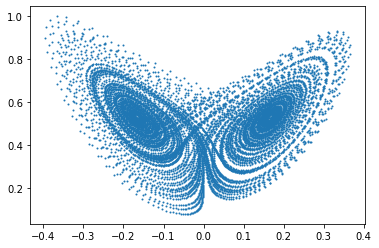

In [29]:
plt.scatter(randpts[:,0],randpts[:,2],s = 1)
#plt.scatter(Voronoi_centers[:,0],Voronoi_centers[:,2])

In [30]:
U_true = Ulam(randpts,Trandpts)

im_true = invariant_measure(U_true)

In [31]:
def Lorenz_vec(x):
    dx = 10 * (x[:,1] - x[:,0])
    dy = x[:,0] * (28 - x[:,2]) - x[:,1]
    dz = x[:,0] * x[:,1] - (8/3) * x[:,2]
    return torch.cat((dx.reshape(len(x),1),dy.reshape(len(x),1),dz.reshape(len(x),1)),dim = 1)

In [32]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
# optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
# net2.train()
N_iters = 10000

net1.train()
loss1 = []
# loss2 = []
invert_variables = [0,1,2]

Iteration 0, Loss(Ours): 54.483253479003906


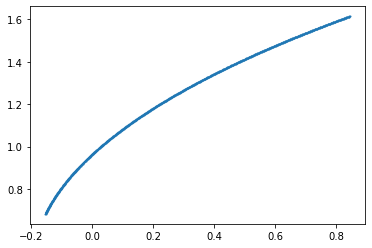

Iteration 1000, Loss(Ours): 0.9701321721076965
Iteration 2000, Loss(Ours): 0.469212144613266
Iteration 3000, Loss(Ours): 0.7765313386917114
Iteration 4000, Loss(Ours): 0.6245852112770081
Iteration 5000, Loss(Ours): 0.6427716016769409


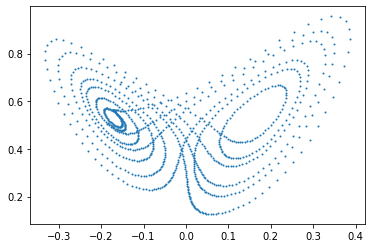

Iteration 6000, Loss(Ours): 0.4938182532787323
Iteration 7000, Loss(Ours): 0.4899938106536865


KeyboardInterrupt: 

In [15]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer1.zero_grad()
    # optimizer2.zero_grad()
    
    # Update for net1 (Ulam)
    # net1_randpts = net1(randpts) #parametrize the map
    net1_randpts = randpts

    V_field = Lorenz_vec(net1_randpts*M_scale)/M_scale
    V_field[:,invert_variables] = net1(net1_randpts)[:,invert_variables]
    net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    #im_net = invariant_measure(U_net)
    #L1 = torch.linalg.matrix_norm(U_net - U_true,ord = 'fro')
    #L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    
    optimizer1.step()
    loss1.append(L1.item())  # Directly use .item() for scalar value

    # Logging
    if i % 1000 == 0:
        print(f'Iteration {i}, Loss(Ours): {L1.item()}')#, Loss(Pointwise): {L2.item()}')
        
    # Visualization every 500 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        # x2 = x1
        vals1= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            V_field = Lorenz_vec(x1*M_scale)/M_scale
            V_field[:,invert_variables] = net1(x1)[:,invert_variables]
            x1 = x1 + V_field*dt
                
            vals1.append(x1.detach().numpy().flatten())

        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
        plt.show()
        # plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        # plt.show()


Iteration 0, Loss(Ours): 0.0012713308678939939


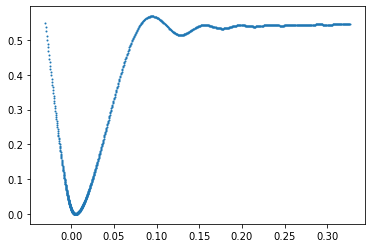

Iteration 1000, Loss(Ours): 7.984203693922609e-05
Iteration 2000, Loss(Ours): 7.146818097680807e-05
Iteration 3000, Loss(Ours): 5.63454523216933e-05
Iteration 4000, Loss(Ours): 4.845105286221951e-05
Iteration 5000, Loss(Ours): 4.1038274503080174e-05


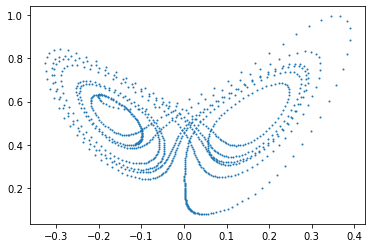

Iteration 6000, Loss(Ours): 2.7188432795810513e-05
Iteration 7000, Loss(Ours): 3.148919131490402e-05
Iteration 8000, Loss(Ours): 4.809030724572949e-05
Iteration 9000, Loss(Ours): 1.971220444829669e-05


In [33]:
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))
optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()
loss2 = []
invert_variables = [0]
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    net2_randpts = randpts

    V_field2 = Lorenz_vec(net2_randpts*M_scale)/M_scale
    V_field2[:,invert_variables] = net2(net2_randpts)[:,invert_variables]
    net2_randpts = net2_randpts+dt* V_field2
    U_net = Ulam(randpts,net2_randpts)
    im_net = invariant_measure(U_net)
    L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    L1.backward()
    optimizer2.step()
    loss2.append(L1.item())  # Directly use .item() for scalar value

    # Logging
    if i % 1000 == 0:
        print(f'Iteration {i}, Loss(Ours): {L1.item()}')#, Loss(Pointwise): {L2.item()}')
        
    # Visualization every 500 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        # x2 = x1
        vals2= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            V_field2 = Lorenz_vec(x1*M_scale)/M_scale
            V_field2[:,invert_variables] = net2(x1)[:,invert_variables]
            x1 = x1 + V_field2*dt
                
            vals2.append(x1.detach().numpy().flatten())

        
        vals2= np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
        plt.show()

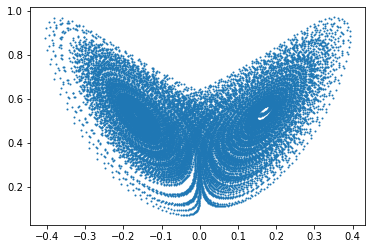

In [17]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    
    V_field = net1(x1)
    x1 = x1 + V_field*dt
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
plt.show()

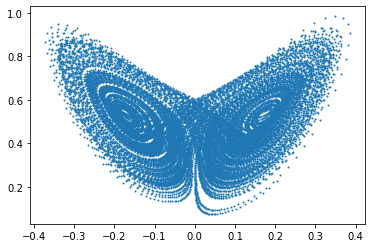

In [34]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals2 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    V_field2 = Lorenz_vec(x1*M_scale)/M_scale
    V_field2[:,invert_variables] = net2(x1)[:,invert_variables]
    x1 = x1 + V_field2*dt
    vals2.append(x1.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
plt.show()

In [35]:

GT = traj(int(simulation_t), M_scale* randpts[0])

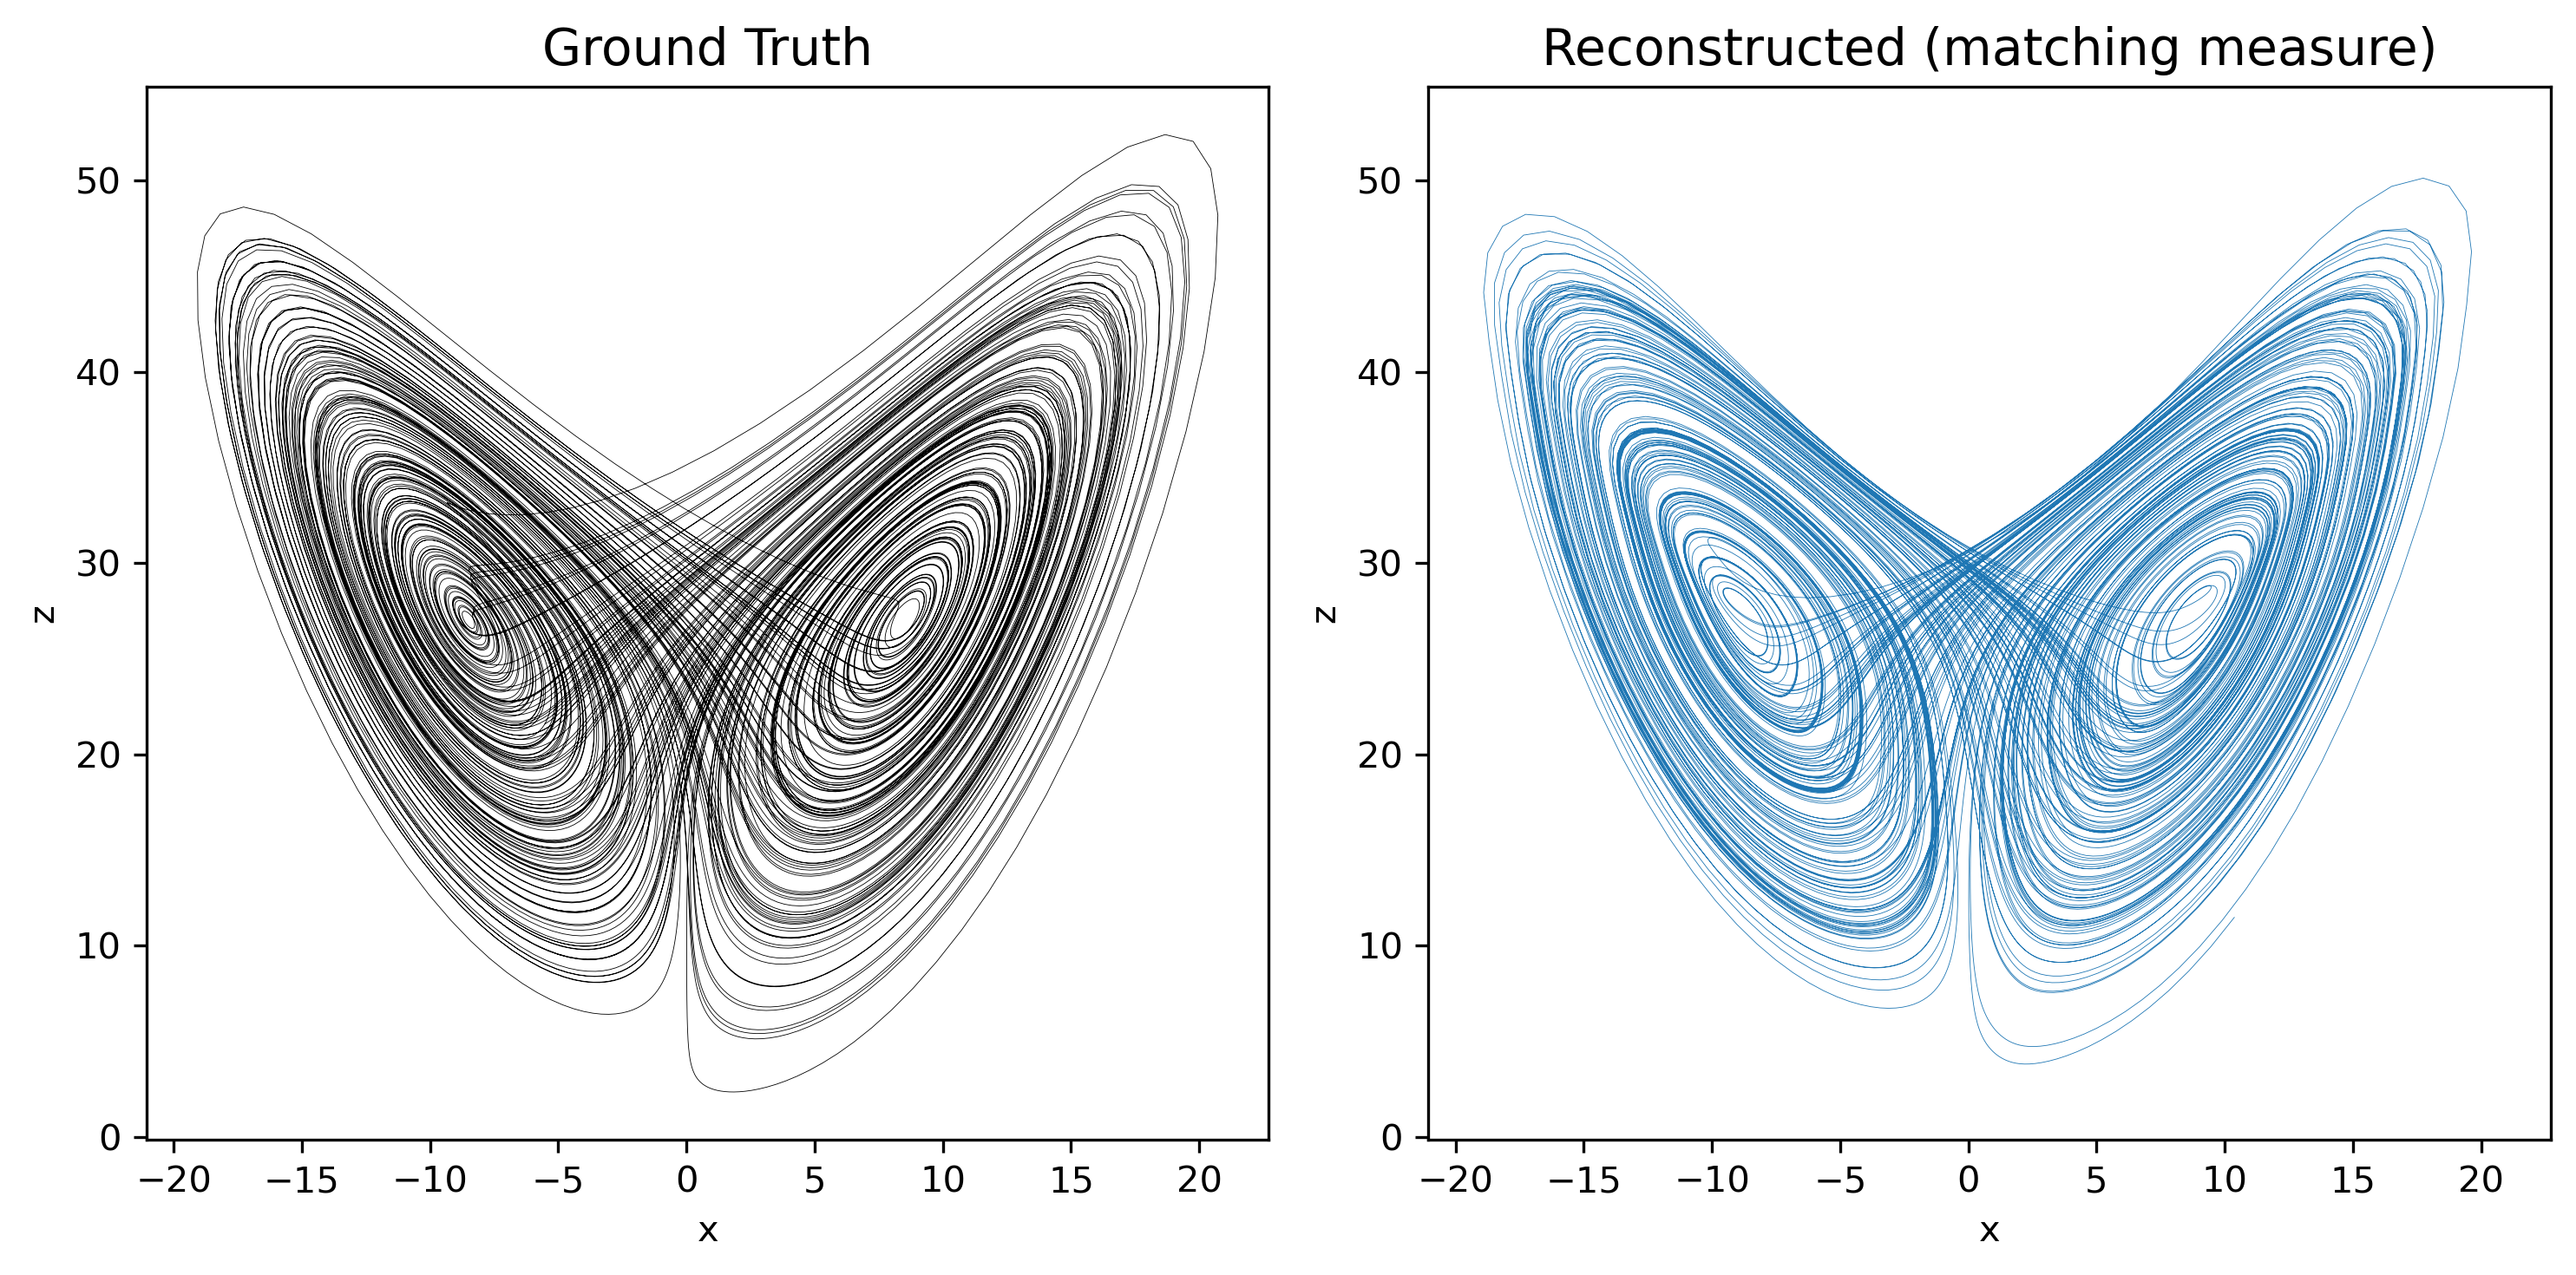

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# First plot: Ground Truth
axes[0].plot(GT[:, 0], GT[:, 2], label="Ground Truth", linewidth=0.2, c="black")
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
axes[0].set_title("Ground Truth",fontsize = 14)

# Save axis limits
xlims = axes[0].get_xlim()
ylims = axes[0].get_ylim()

# Second plot: Reconstructed Trajectory (matching matrix)
axes[1].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 2], linewidth=0.2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
axes[1].set_title("Reconstructed (matching measure)",fontsize = 14)
axes[1].set_xlim(xlims)
axes[1].set_ylim(ylims)

plt.tight_layout()
plt.show()
